## Importing Libraries

In [1]:
import os

os.environ['TF_USE_LEGACY_KERAS'] = '1'
import nltk
import pandas as pd
import numpy as np
import tensorflow as tf
import string
from nltk.stem import PorterStemmer, WordNetLemmatizer
from bs4 import BeautifulSoup
from nltk.tokenize import word_tokenize

In [19]:
##Downloading nltk packages
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abdel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abdel\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Loading Dataset

In [ ]:
data = pd.read_csv('IMDB Dataset.csv')
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


### 📊 Charger le Dataset
- **Objectif**: Importer les données d'entraînement (avis IMDB avec sentiment positif/négatif).
- **Structure**: Chaque ligne contient un avis texte et son sentiment (positive/negative).
- **Prochaine étape**: Nettoyer les données manquantes et préparer le texte.

In [21]:
df = data.dropna()

In [22]:
data.shape

(50000, 2)

In [23]:
df.shape

(50000, 2)

In [24]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


### Text Preprocessing - Basics


#### 🔹 Stemming
- **Goal**: Cut off prefixes or suffixes to get the root form of a word (*stem*).
- **How it works**: Uses simple rules to chop off word endings. It doesn’t check if the result is a valid word.
- **Examples**:
  - `"playing"` → `"play"`
  - `"played"` → `"play"`
  - `"flies"` → `"fli"` ❌ *(not a real word)*
- **Think of it like**: A quick-and-dirty way of shortening words.
- **Use case**: When speed matters more than accuracy (e.g., search engines).

In [25]:
##Stemming
st = PorterStemmer()
print("Stemming")
print("Playing ->", st.stem("Playing"))
print("Played ->", st.stem("Played"))
print("flies ->", st.stem("flies"))

Stemming
Playing -> play
Played -> play
flies -> fli


#### 🔹 Lemmatization
- **Goal**: Convert a word to its **dictionary form** (*lemma*), considering its **meaning** and **part of speech**.
- **How it works**: Uses vocabulary and grammar rules to return real words.
- **Examples**:
  - `"playing"` → `"play"`
  - `"better"` → `"good"`
  - `"flies"` → `"fly"` ✅ *(real word)*
- **Think of it like**: A smarter, more accurate version of stemming.
- **Use case**: When understanding and accuracy matter (e.g., chatbots, NLP pipelines).

In [26]:
##Lemmatization
lm = WordNetLemmatizer()
print("Lemmatization")
print("Playing ->", lm.lemmatize("Playing"))
print("Played ->", lm.lemmatize("Played"))
print("flies ->", lm.lemmatize("flies"))

Lemmatization
Playing -> Playing
Played -> Played
flies -> fly


## Text Preprocessing

### 🧹 Nettoyage du Texte

**Étapes appliquées à chaque avis**:
1. **HTML**: Supprimer les balises HTML (ex: `<br>` → rien)
2. **Minuscules**: Convertir en minuscules pour uniformité
3. **Contractions**: "don't" → "do not", "I'm" → "I am"
4. **Slang**: "u" → "you", "gr8" → "great"
5. **URLs**: Supprimer tous les liens web
6. **Caractères spéciaux**: Garder seulement lettres et espaces
7. **Tokenization**: Diviser en mots individuels

**Résultat**: Texte standardisé et prêt pour le modèle

In [6]:
punctuation = string.punctuation
stopwords = nltk.corpus.stopwords.words('english')
lm = WordNetLemmatizer()

In [13]:
import re
import contractions
from bs4 import BeautifulSoup

# dictionnaire slang / internet / txt speak
slang_dict = {
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of",
    "lemme": "let me",
    "gimme": "give me",
    "outta": "out of",
    "dunno": "do not know",

    # txt speak
    "u": "you",
    "r": "are",
    "ur": "your",
    "gr8": "great",
    "b4": "before",
    "l8r": "later",
    "idk": "i do not know",
    "imo": "in my opinion"
}

In [14]:
def normalize_slang(text):
    words = text.split()
    new_words = []

    for w in words:
        if w in slang_dict:
            new_words.append(slang_dict[w])
        else:
            new_words.append(w)

    return " ".join(new_words)

In [15]:
def clean_text(text):
    # 1. HTML removal
    text = BeautifulSoup(text, "html.parser").get_text()

    # 2. lowercase
    text = text.lower()

    # 3. expand contractions (don't → do not)
    text = contractions.fix(text)

    # 4. normalize slang (gonna → going to, u → you, etc.)
    text = normalize_slang(text)

    # 5. remove URLs
    text = re.sub(r"http\S+", "", text)

    # 6. remove special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # 7. tokenize
    tokens = text.split()

    # 8. remove very short tokens
    tokens = [t for t in tokens if len(t) > 1]

    return " ".join(tokens)

In [31]:
X = df['review'].apply(lambda x: clean_text(x))

In [32]:
Y = df = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0)

In [33]:
Y

0        1
1        1
2        1
3        0
4        1
        ..
49995    1
49996    0
49997    0
49998    0
49999    0
Name: sentiment, Length: 50000, dtype: int64

In [34]:
##Average num of words in text
sum=0
for i in X.to_list():
    sum+=len(i.split(" "))
avg = sum/len(X.to_list())
avg


222.29012

In [35]:
#Splitting dataset
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25)

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM,Embedding,TextVectorization, Dropout

## Text Vectorization

### 🔢 Vectorisation du Texte

- **Objectif**: Convertir le texte en nombres pour que le modèle puisse le traiter.
- **Comment ça marche**: 
  - Créer un vocabulaire de 20 000 mots les plus fréquents
  - Remplacer chaque mot par son index (numéro)
  - Toutes les séquences ont la même longueur (200 mots max)
- **Exemple**: `"film excellent"` → `[154, 3021]`
- **Pourquoi**: Les réseaux de neurones ne comprennent que les nombres, pas le texte.

In [37]:
vocab_size = 20000
max_len = 200
vectorize_layer = TextVectorization(
 max_tokens=vocab_size,
 output_mode='int',
 output_sequence_length=max_len)

In [38]:
# build the vocabulary
vectorize_layer.adapt(X_train)

In [39]:
vocab = np.array(vectorize_layer.get_vocabulary())
#First 50 vocabulary
vocab[:50]

array(['', '[UNK]', 'the', 'and', 'of', 'is', 'to', 'it', 'in', 'this',
       'that', 'not', 'was', 'as', 'movie', 'for', 'with', 'but', 'film',
       'you', 'on', 'are', 'have', 'he', 'his', 'one', 'be', 'at', 'all',
       'they', 'by', 'an', 'who', 'so', 'from', 'like', 'there', 'or',
       'do', 'just', 'her', 'out', 'if', 'about', 'has', 'what', 'would',
       'some', 'good', 'more'], dtype='<U17')

In [40]:
x1 = vectorize_layer(X_train.to_list())

In [41]:
X_train.shape

(37500,)

In [42]:
x1

<tf.Tensor: shape=(37500, 200), dtype=int64, numpy=
array([[   8,   54,    3, ...,   19,   63,  221],
       [   2,    1,  109, ..., 7564,  229,    4],
       [   8,   58,  637, ...,    0,    0,    0],
       ...,
       [ 122,   96,    1, ...,    0,    0,    0],
       [   9,   12,    2, ...,    0,    0,    0],
       [   8, 2645,    4, ...,    0,    0,    0]], dtype=int64)>

In [43]:
vocab

array(['', '[UNK]', 'the', ..., 'decisive', 'deceiving', 'debated'],
      dtype='<U17')

In [44]:
##Search indices of word
foleys = np.where(vocab == 'noir')
foleys

(array([1504], dtype=int64),)

In [45]:
X_train.to_list()[2]

'in my opinion october sky is one of the best movies of it totally has everything an emotional drama movie would need like wonderful story and good character interactions october sky will remain in heart for as long as can remember and just have to say very special thanks to those who have created this film'

In [46]:
x1[2,:]

<tf.Tensor: shape=(200,), dtype=int64, numpy=
array([   8,   58,  637, 7835, 2325,    5,   25,    4,    2,  116,   97,
          4,    7,  429,   44,  258,   31,  848,  425,   14,   46,  340,
         35,  378,   61,    3,   48,  103, 5240, 7835, 2325,   53, 2162,
          8,  462,   15,   13,  182,   13,   67,  366,    3,   39,   22,
          6,  129,   52,  298, 1147,    6,  142,   32,   22, 1022,    9,
         18,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
     

## Building LSTM Model

### 🧠 Architecture du Modèle LSTM avec Attention

**Couches du modèle**:
1. **Embedding**: Convertit les indices en vecteurs denses (100 dimensions)
2. **LSTM**: Capture les dépendances à long terme dans le texte
3. **Attention (Bahdanau)**: Identifie les mots importants pour la prédiction
4. **Dense + Dropout**: Réduit le surapprentissage
5. **Output (Sigmoid)**: Prédit positif (1) ou négatif (0)

**Pourquoi Attention?** Le modèle apprend quels mots sont les plus importants (ex: "mauvais", "excellent") pour décider le sentiment.

In [205]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
import tensorflow.keras.backend as K

class BahdanauAttention(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                               initializer="normal")
        self.b = self.add_weight(name="att_bias", shape=(input_shape[1], 1),
                               initializer="zeros")
        super().build(input_shape)

    def call(self, x, mask=None):
        e = K.tanh(K.dot(x, self.W) + self.b)
        a = K.softmax(e, axis=1)
        
        if mask is not None:
            mask = K.cast(mask, K.floatx())
            mask = K.expand_dims(mask, axis=-1)
            a = a * mask
            a = a / (K.sum(a, axis=1, keepdims=True) + K.epsilon())
            
        output = x * a
        return K.sum(output, axis=1)

    def compute_mask(self, input, mask):
        return None

    def get_config(self):
        return super().get_config()

In [206]:
model = Sequential()
# (1,) (because we need to guarantee that there is exactly one string
# input per batch), and the dtype needs to be 'string'.
model.add(tf.keras.Input(shape=(1,), dtype=tf.string))

model.add(vectorize_layer)
model.add(Embedding(vocab_size, 100, mask_zero=True))
model.add(LSTM(100, return_sequences=True))
model.add(tf.keras.layers.BatchNormalization())
model.add(BahdanauAttention())
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))
model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 text_vectorization_4 (Text  (None, 200)               0         
 Vectorization)                                                  
                                                                 
 embedding_4 (Embedding)     (None, 200, 100)          2000000   
                                                                 
 lstm_4 (LSTM)               (None, 200, 100)          80400     
                                                                 
 batch_normalization_4 (Bat  (None, 200, 100)          400       
 chNormalization)                                                
                                                                 
 bahdanau_attention_1 (Bahd  (None, 100)               300       
 anauAttention)                                                  
                                                      

In [207]:
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

## Model Training

### 🎯 Entraînement du Modèle

- **Batch size** 32: Traiter 32 avis à la fois pour optimiser l'apprentissage
- **Epochs** 10: Parcourir le dataset 10 fois maximum
- **Early Stopping**: Arrêter l'entraînement si la perte de validation augmente pendant 2 epochs
- **Validation**: Tester sur l'ensemble de test durante l'entraînement pour éviter le surapprentissage
- **Optimiseur** Adam: Ajuste automatiquement les poids du modèle

In [208]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(X_train,Y_train,validation_data=(X_test,Y_test),batch_size=32,epochs=10,
                    callbacks = [early_stop])

Epoch 1/10
1172/1172 [==============================] - 152s 128ms/step - loss: 0.3326 - accuracy: 0.8556 - val_loss: 0.2795 - val_accuracy: 0.8833
Epoch 2/10
1172/1172 [==============================] - 206s 176ms/step - loss: 0.1900 - accuracy: 0.9276 - val_loss: 0.3309 - val_accuracy: 0.8634
Epoch 3/10
1172/1172 [==============================] - 198s 169ms/step - loss: 0.1169 - accuracy: 0.9566 - val_loss: 0.4187 - val_accuracy: 0.8714


In [ ]:
##Saving Model
model.save("./Sentiment_Classifier_lstm_attention")

NameError: name 'model' is not defined

### Accuracy Visualization

In [2]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],label='Training Acc')
plt.plot(history.history['val_accuracy'],label='Test Acc')
plt.legend()
plt.show()

NameError: name 'history' is not defined

### Testing Model on random text

In [20]:
Test_text = 'that is  bad'
text_cleaned = clean_text(Test_text)
prediction = model.predict(np.array([text_cleaned]))
if(prediction[0]>0.5):
    print("Positive Sentiment", "\nScore:",prediction[0][0])
else:
    print("Negative Sentiment","\nScore:",prediction[0][0])

1/1 [==============================] - 0s 41ms/step
Negative Sentiment 
Score: 0.0012863263


In [18]:
Test_text = 'not good. The movie was bad. I would not recommend it.'
prediction = model.predict(np.array([Test_text]))
if(prediction[0]>0.5):
    print("Positive Sentiment", "\nScore:",prediction[0][0])
else:
    print("Negative Sentiment","\nScore:",prediction[0][0])

1/1 [==============================] - 0s 38ms/step
Negative Sentiment 
Score: 0.0021372612


In [213]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Model Evaluation

### 📈 Métriques de Performance

- **Precision**: % des avis prédits positifs qui sont vraiment positifs
- **Recall**: % des avis positifs réels correctement identifiés
- **F1-score**: Moyenne harmonique entre Precision et Recall
- **Confusion Matrix**: Visualise les vraies/fausses prédictions (TP, FP, TN, FN)

In [48]:
type(X_test)

pandas.Series

In [49]:
y_pred = model.predict(X_test.to_list())
y_pred_binary = np.where(y_pred > 0.5, 1, 0)
y_pred_binary

391/391 [==============================] - 21s 53ms/step


array([[1],
       [0],
       [1],
       ...,
       [0],
       [1],
       [0]])

In [50]:
y_pred_binary.shape

(12500, 1)

In [51]:
y_true = np.array([Y_test.to_list()]).T
y_true.shape

(12500, 1)

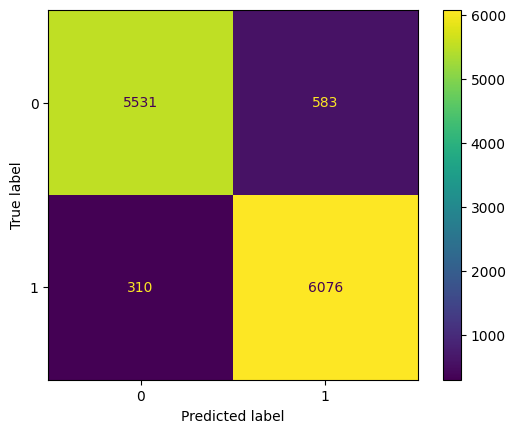

In [52]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix(y_true,y_pred_binary))
disp.plot()

In [219]:
print(classification_report(y_true, y_pred_binary))

              precision    recall  f1-score   support

           0       0.93      0.83      0.88      6297
           1       0.84      0.94      0.89      6203

    accuracy                           0.88     12500
   macro avg       0.89      0.88      0.88     12500
weighted avg       0.89      0.88      0.88     12500

